In [21]:
!pip install docker psutil

In [22]:
import docker
import pandas as pd
import time

client = docker.from_env()

print("Docker Connected Successfully")

Docker Connected Successfully


In [23]:
for container in client.containers.list():
    print(container.name)

fraud-backend
fraud-postgres


In [24]:
container = client.containers.get("fraud-backend")

cpu_usage = []
memory_usage = []

for i in range(60):

    stats = container.stats(stream=False)

    cpu_percent = (
        (stats["cpu_stats"]["cpu_usage"]["total_usage"]
         - stats["precpu_stats"]["cpu_usage"]["total_usage"])
        /
        (stats["cpu_stats"]["system_cpu_usage"]
         - stats["precpu_stats"]["system_cpu_usage"])
    ) * 100

    mem_mb = stats["memory_stats"]["usage"] / (1024**2)

    cpu_usage.append(cpu_percent)
    memory_usage.append(mem_mb)

    time.sleep(1)

print("Monitoring Complete")

KeyboardInterrupt: 

In [ ]:
results = pd.DataFrame({
    "Metric":[
        "Average CPU %",
        "Peak CPU %",
        "Average Memory MB",
        "Peak Memory MB"
    ],
    "Value":[
        sum(cpu_usage)/len(cpu_usage),
        max(cpu_usage),
        sum(memory_usage)/len(memory_usage),
        max(memory_usage)
    ]
})

results

,Metric,Value
0,Average CPU %,0.086978
1,Peak CPU %,0.788200
2,Average Memory MB,330.874674
3,Peak Memory MB,331.816406


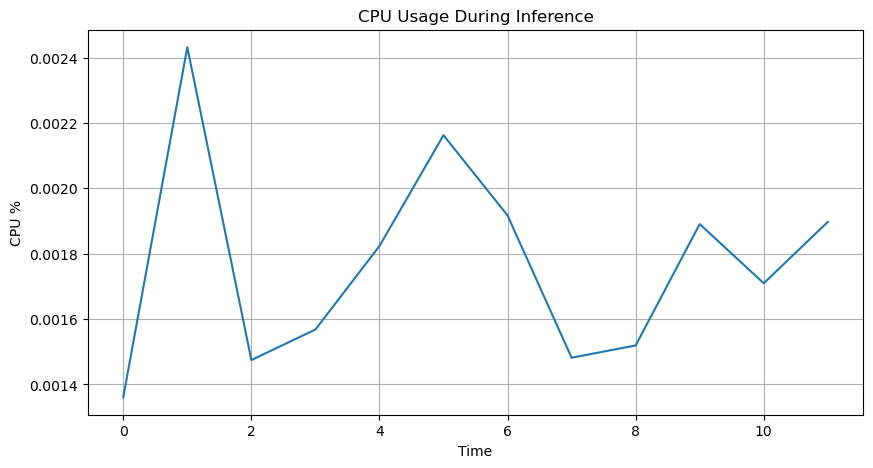

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cpu_usage)
plt.title("CPU Usage During Inference")
plt.xlabel("Time")
plt.ylabel("CPU %")
plt.grid(True)
plt.show()

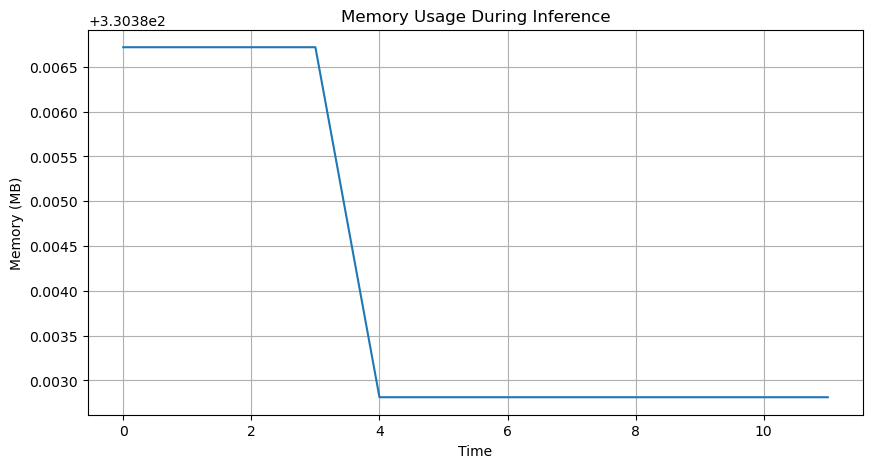

In [26]:
plt.figure(figsize=(10,5))
plt.plot(memory_usage)
plt.title("Memory Usage During Inference")
plt.xlabel("Time")
plt.ylabel("Memory (MB)")
plt.grid(True)
plt.show()